# Кластеризация сигналов сцинтилляционного детектора

**Цель работы:** автоматически разделить сигналы сцинтилляционного детектора на три группы:

- 0 — первый тип частиц;
- 1 — второй тип частиц;
- 2 — аномальные, смешанные или плохо идентифицируемые сигналы.

Задача решается методами машинного обучения без учителя. Основная идея решения — не подавать в модель все 500 отсчётов напрямую, а сначала выделить физически осмысленные признаки формы импульса: амплитуду, интегралы, долю хвоста, время затухания, отношение сигнал/шум и временные характеристики.

В ноутбуке последовательно выполнены:

1. загрузка и первичный анализ данных;
2. предобработка сигналов;
3. Feature Engineering;
4. анализ и отбор признаков;
5. сравнение нескольких моделей и гиперпараметров;
6. выбор финальной модели;
7. формирование файла submission.csv для Kaggle;
8. интерпретация кластеров и выводы.


## Воспроизводимость

Для воспроизводимости зафиксирован RANDOM_STATE. Все случайные выборки, модели и разбиения используют это значение.  
Перед запуском положите файл с исходными сигналами Run200_Wave_0_1.txt в одну папку с ноутбуком или укажите путь к нему в списке DATA_FILE_CANDIDATES.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from scipy.optimize import curve_fit
from sklearn.cluster import Birch, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random_generator = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

ADC_FULL_SCALE = 2**14
BASELINE_OFFSET = 1560
EXPECTED_SIGNAL_COUNT = 23_479
EXPECTED_CHANNEL_COUNT = 500

HIGH_PSD_PARTICLE_CLUSTER = 0
LOW_PSD_PARTICLE_CLUSTER = 1
ANOMALY_CLUSTER = 2


## 1. Загрузка данных

В исходном файле первые служебные столбцы не являются отсчётами формы сигнала. После их удаления остаётся матрица сигналов: строки — отдельные события, столбцы — временные каналы.


In [2]:
DATA_FILE_CANDIDATES = [
    Path("Run200_Wave_0_1.txt"),
    Path("/kaggle/input/signal-types-classification/Run200_Wave_0_1.txt"),
    Path("/kaggle/input/signal-types-classification/Run200_Wave_0_1.csv"),
]


def find_existing_file(file_candidates: list[Path]) -> Path:
    """Return the first existing path from a list of possible data locations."""
    for file_path in file_candidates:
        if file_path.exists():
            return file_path

    candidates_as_text = "\n".join(str(path) for path in file_candidates)
    raise FileNotFoundError(
        "Не найден файл с сигналами. Проверьте список DATA_FILE_CANDIDATES:\n"
        f"{candidates_as_text}"
    )


data_file_path = find_existing_file(DATA_FILE_CANDIDATES)
print(f"Используемый файл данных: {data_file_path}")

raw_waveform_table = pd.read_csv(
    data_file_path,
    sep=r"\s+",
    header=None,
    engine="python",
)

metadata_column_indices = [0, 1, 2, 3]
trailing_column_indices = [504] if 504 in raw_waveform_table.columns else []
columns_to_drop = metadata_column_indices + trailing_column_indices

waveform_channel_table = raw_waveform_table.drop(
    columns=columns_to_drop,
    errors="ignore",
).copy()

if waveform_channel_table.shape[1] > EXPECTED_CHANNEL_COUNT:
    waveform_channel_table = waveform_channel_table.iloc[:, :EXPECTED_CHANNEL_COUNT].copy()

waveform_channel_table.columns = range(waveform_channel_table.shape[1])

corrected_waveforms = (ADC_FULL_SCALE - waveform_channel_table - BASELINE_OFFSET).clip(
    lower=0
)

print(f"Размер исходной таблицы: {raw_waveform_table.shape}")
print(f"Размер таблицы сигналов после предобработки: {corrected_waveforms.shape}")

if corrected_waveforms.shape[0] != EXPECTED_SIGNAL_COUNT:
    print(
        "Предупреждение: количество сигналов отличается от ожидаемых "
        f"{EXPECTED_SIGNAL_COUNT}. Проверьте версию файла."
    )

if corrected_waveforms.shape[1] != EXPECTED_CHANNEL_COUNT:
    print(
        "Предупреждение: количество каналов отличается от ожидаемых "
        f"{EXPECTED_CHANNEL_COUNT}. Проверьте формат файла."
    )

display(corrected_waveforms.head())


Используемый файл данных: Run200_Wave_0_1.txt
Размер исходной таблицы: (23479, 504)
Размер таблицы сигналов после предобработки: (23479, 500)


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,4,1,0,2,6,4,0,2,4,4,...,0,2,9,9,7,5,4,2,4,5
1,4,2,4,0,0,2,4,2,1,3,...,0,7,0,2,0,5,4,5,2,4
2,4,4,2,0,4,0,0,5,1,0,...,4,3,4,4,6,3,1,4,4,3
3,0,2,6,0,0,2,4,2,0,4,...,0,0,2,3,4,0,4,2,1,2
4,1,9,1,3,0,4,1,0,8,3,...,4,4,1,0,0,4,0,0,2,0


## 2. EDA: первичный анализ сигналов

На этом этапе проверяем размерность, пропуски, диапазоны значений и форму нескольких случайных импульсов. Это нужно, чтобы понять, есть ли явные технические проблемы и какие признаки стоит извлекать.


In [3]:
missing_value_count = int(corrected_waveforms.isna().sum().sum())
preliminary_peak_amplitudes = corrected_waveforms.max(axis=1)
preliminary_integral_values = corrected_waveforms.sum(axis=1)
preliminary_peak_positions = corrected_waveforms.idxmax(axis=1)

eda_overview = pd.DataFrame(
    {
        "metric": [
            "signal_count",
            "channel_count",
            "missing_values",
            "min_value",
            "max_value",
            "median_peak_amplitude",
            "median_integral",
            "median_peak_position",
        ],
        "value": [
            corrected_waveforms.shape[0],
            corrected_waveforms.shape[1],
            missing_value_count,
            float(corrected_waveforms.min().min()),
            float(corrected_waveforms.max().max()),
            float(preliminary_peak_amplitudes.median()),
            float(preliminary_integral_values.median()),
            float(preliminary_peak_positions.median()),
        ],
    }
)

display(eda_overview)

channel_statistics = corrected_waveforms.describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

display(channel_statistics.iloc[::50])


,metric,value
0,signal_count,23479.0
1,channel_count,500.0
2,missing_values,0.0
3,min_value,0.0
4,max_value,14824.0
5,median_peak_amplitude,814.0
6,median_integral,6975.0
7,median_peak_position,150.0


,count,mean,std,min,1%,5%,50%,95%,99%,max
0,23479.0,1.683291,1.979611,0.0,0.0,0.0,1.0,5.0,7.00,12.0
50,23479.0,1.712509,2.002761,0.0,0.0,0.0,1.0,5.0,7.00,12.0
100,23479.0,1.697985,2.005629,0.0,0.0,0.0,1.0,6.0,7.00,14.0
150,23479.0,1592.086673,1904.907097,22.0,50.0,78.0,803.0,5810.2,8466.44,13252.0
200,23479.0,13.611696,15.723661,0.0,0.0,0.0,8.0,46.0,72.00,129.0
250,23479.0,6.112739,6.964028,0.0,0.0,0.0,4.0,20.0,32.00,62.0
300,23479.0,4.126965,4.595238,0.0,0.0,0.0,3.0,13.0,20.00,47.0
350,23479.0,3.290898,3.662264,0.0,0.0,0.0,2.0,10.0,16.00,39.0
400,23479.0,2.779548,3.101864,0.0,0.0,0.0,2.0,9.0,13.00,28.0
450,23479.0,2.478172,2.740257,0.0,0.0,0.0,2.0,7.0,12.00,27.0


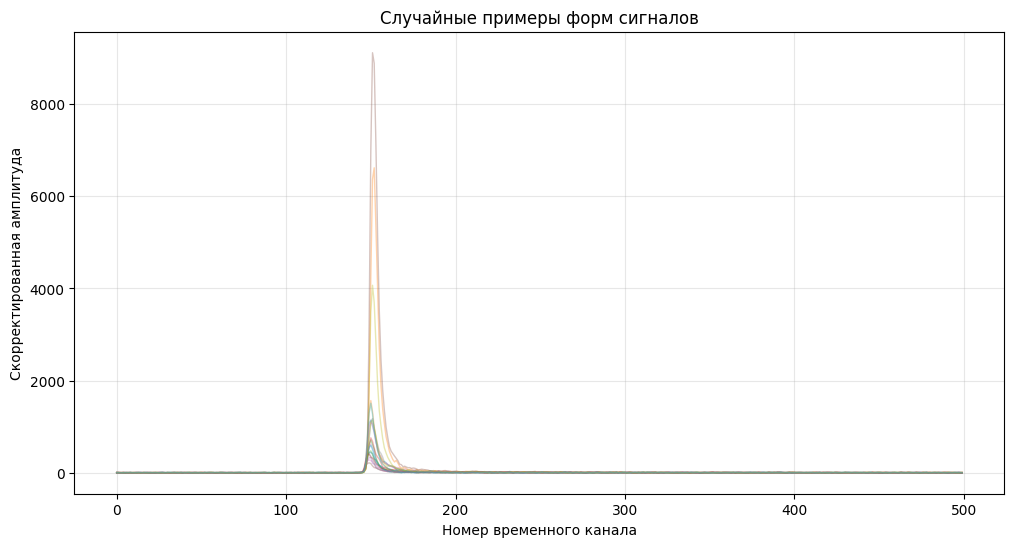

In [4]:
sample_size_for_plots = min(20, len(corrected_waveforms))
sampled_signal_indices = random_generator.choice(
    corrected_waveforms.index,
    size=sample_size_for_plots,
    replace=False,
)

plt.figure(figsize=(12, 6))
for signal_index in sampled_signal_indices:
    plt.plot(
        corrected_waveforms.columns,
        corrected_waveforms.loc[signal_index],
        alpha=0.35,
        linewidth=1,
    )
plt.title("Случайные примеры форм сигналов")
plt.xlabel("Номер временного канала")
plt.ylabel("Скорректированная амплитуда")
plt.grid(alpha=0.3)
plt.show()


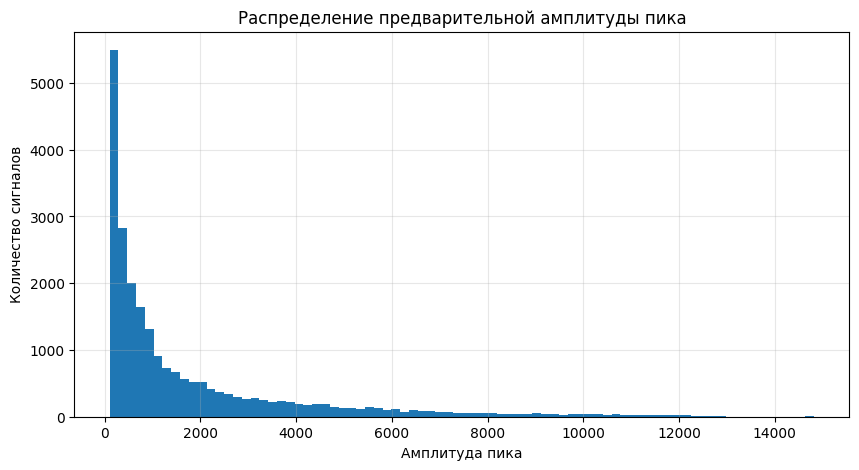

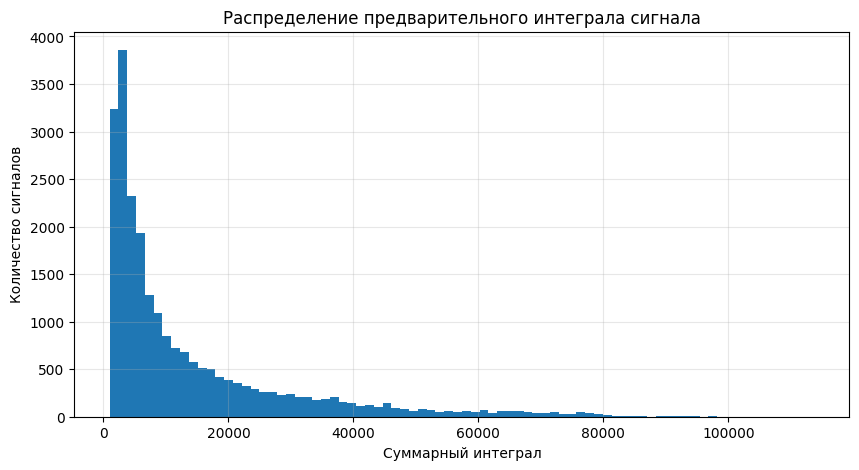

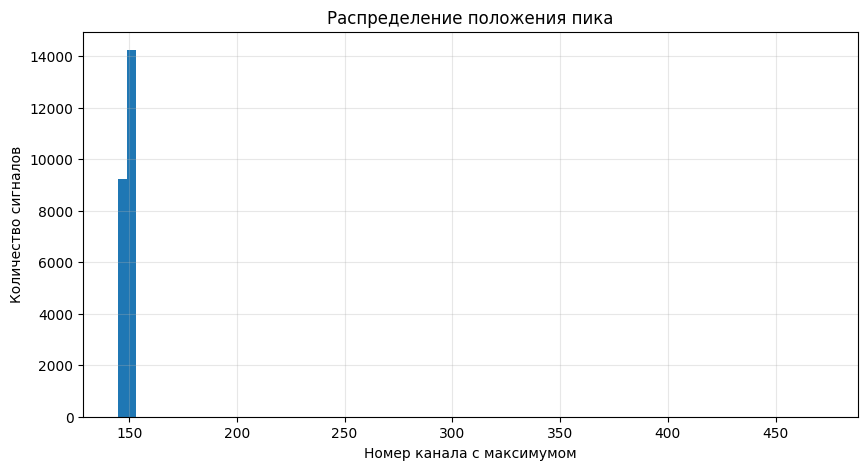

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(preliminary_peak_amplitudes, bins=80)
plt.title("Распределение предварительной амплитуды пика")
plt.xlabel("Амплитуда пика")
plt.ylabel("Количество сигналов")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(preliminary_integral_values, bins=80)
plt.title("Распределение предварительного интеграла сигнала")
plt.xlabel("Суммарный интеграл")
plt.ylabel("Количество сигналов")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(preliminary_peak_positions, bins=80)
plt.title("Распределение положения пика")
plt.xlabel("Номер канала с максимумом")
plt.ylabel("Количество сигналов")
plt.grid(alpha=0.3)
plt.show()


### Вывод по EDA

1. После удаления служебных столбцов данные содержат 23 479 сигнала и 500 временных каналов.  
2. Пропусков не обнаружено, поэтому дополнительное заполнение или удаление строк не требуется.  
3. Пик большинства импульсов расположен около 150-го канала, что указывает на согласованную временную привязку сигналов.  
4. Распределения амплитуд и интегралов имеют длинный правый хвост, поэтому дальше используется RobustScaler, менее чувствительный к выбросам.  
5. Для разделения гамма-квантов, нейтронов и неоднозначных сигналов важна не только высота пика, но и форма хвостовой части импульса.


## 3. Feature Engineering

Для каждого сигнала извлекаются признаки, которые описывают форму импульса:

- амплитуда пика;
- суммарный заряд/интеграл;
- доля хвостовой части импульса (PSD-признаки);
- оценка времени экспоненциального затухания;
- временной центр масс импульса;
- ширина импульса;
- отношение сигнал/шум;
- асимметрия и эксцесс формы.

Такие признаки устойчивее и интерпретируемее, чем непосредственная кластеризация по 500 каналам.


In [6]:
PEDESTAL_WINDOW_SIZE = 50
MIN_SIGNAL_TO_NOISE = 3.0
MIN_PEAK_POSITION = 10
DECAY_FIT_START_FRACTION = 0.40
EPSILON = 1e-6


def estimate_decay_tau(signal_window: np.ndarray, start_position: int) -> float:
    """Estimate exponential decay time for the signal tail."""
    try:
        time_axis = np.arange(len(signal_window) - start_position, dtype=float)
        tail_values = signal_window[start_position:].clip(min=EPSILON)

        if len(time_axis) <= 3 or tail_values[0] <= 0:
            return np.nan

        optimal_parameters, _ = curve_fit(
            lambda time, amplitude, tau: amplitude * np.exp(-time / tau),
            time_axis,
            tail_values,
            p0=[tail_values[0], 5.0],
            maxfev=500,
            bounds=([0, 0.1], [np.inf, 500]),
        )
        return float(optimal_parameters[1])
    except Exception:
        return np.nan


def calculate_signal_features(waveform_values: np.ndarray) -> dict[str, float] | None:
    """Extract physically motivated features from one waveform."""
    waveform = waveform_values.astype(float)

    pedestal_mean = float(waveform[:PEDESTAL_WINDOW_SIZE].mean())
    pedestal_noise = float(waveform[:PEDESTAL_WINDOW_SIZE].std(ddof=0) + EPSILON)
    centered_waveform = waveform - pedestal_mean

    peak_position = int(np.argmax(centered_waveform))
    peak_amplitude = float(centered_waveform[peak_position])

    if peak_amplitude < MIN_SIGNAL_TO_NOISE * pedestal_noise:
        return None

    if peak_position < MIN_PEAK_POSITION:
        return None

    signal_end_position = len(centered_waveform)
    noise_threshold = MIN_SIGNAL_TO_NOISE * pedestal_noise
    for channel_position in range(peak_position, len(centered_waveform)):
        if centered_waveform[channel_position] < noise_threshold:
            signal_end_position = channel_position
            break

    signal_window = centered_waveform[peak_position:signal_end_position]
    if len(signal_window) < 5:
        return None

    positive_tail_after_peak = centered_waveform[peak_position:].clip(min=0)
    total_integral = float(np.sum(positive_tail_after_peak))
    window_integral = float(np.sum(signal_window))

    prompt_integral_5 = float(np.sum(signal_window[: min(5, len(signal_window))]))
    prompt_integral_10 = float(np.sum(signal_window[: min(10, len(signal_window))]))
    prompt_integral_15 = float(np.sum(signal_window[: min(15, len(signal_window))]))
    prompt_integral_20 = float(np.sum(signal_window[: min(20, len(signal_window))]))

    psd_tail_fraction_10 = float(
        (window_integral - prompt_integral_10) / (window_integral + EPSILON)
    )

    decay_start_position = 2
    for local_position, signal_value in enumerate(signal_window):
        if signal_value < DECAY_FIT_START_FRACTION * peak_amplitude:
            decay_start_position = max(local_position, 2)
            break
    exponential_decay_tau = estimate_decay_tau(signal_window, decay_start_position)

    local_time_axis = np.arange(len(signal_window), dtype=float)
    charge_center_time = float(
        np.sum(local_time_axis * signal_window) / (window_integral + EPSILON)
    )
    charge_time_spread = float(
        np.sqrt(
            np.sum((local_time_axis - charge_center_time) ** 2 * signal_window)
            / (window_integral + EPSILON)
        )
    )

    tail_after_20 = float(np.sum(signal_window[min(20, len(signal_window)) :]))
    tail_fraction_20 = float(tail_after_20 / (window_integral + EPSILON))

    centered_signal = signal_window - signal_window.mean()
    signal_standard_deviation = float(signal_window.std(ddof=0))
    if signal_standard_deviation > EPSILON:
        normalized_signal = centered_signal / signal_standard_deviation
        waveform_skewness = float(np.mean(normalized_signal**3))
        waveform_kurtosis = float(np.mean(normalized_signal**4))
    else:
        waveform_skewness = 0.0
        waveform_kurtosis = 0.0

    return {
        "source_index": np.nan,
        "peak_amplitude": peak_amplitude,
        "total_integral": total_integral,
        "window_integral": window_integral,
        "psd_tail_fraction_10": psd_tail_fraction_10,
        "exponential_decay_tau": exponential_decay_tau,
        "signal_duration": float(len(signal_window)),
        "tail_fraction_20": tail_fraction_20,
        "charge_center_time": charge_center_time,
        "charge_time_spread": charge_time_spread,
        "waveform_skewness": waveform_skewness,
        "waveform_kurtosis": waveform_kurtosis,
        "prompt_fraction_5": float(prompt_integral_5 / (window_integral + EPSILON)),
        "prompt_fraction_10": float(prompt_integral_10 / (window_integral + EPSILON)),
        "prompt_fraction_15": float(prompt_integral_15 / (window_integral + EPSILON)),
        "prompt_fraction_20": float(prompt_integral_20 / (window_integral + EPSILON)),
        "peak_position": float(peak_position),
        "pedestal_noise": pedestal_noise,
        "signal_to_noise": float(peak_amplitude / pedestal_noise),
    }


In [7]:
feature_records: list[dict[str, float]] = []
rejected_signal_indices: list[int] = []

for original_signal_index, waveform_series in corrected_waveforms.iterrows():
    signal_features = calculate_signal_features(waveform_series.to_numpy(dtype=float))

    if signal_features is None:
        rejected_signal_indices.append(int(original_signal_index))
        continue

    signal_features["source_index"] = int(original_signal_index)
    feature_records.append(signal_features)

signal_feature_table = pd.DataFrame(feature_records)

if signal_feature_table.empty:
    raise RuntimeError("Не удалось извлечь признаки ни для одного сигнала.")

numeric_feature_columns = [
    column_name
    for column_name in signal_feature_table.columns
    if column_name != "source_index"
]

signal_feature_table[numeric_feature_columns] = signal_feature_table[
    numeric_feature_columns
].replace([np.inf, -np.inf], np.nan)

for column_name in numeric_feature_columns:
    median_value = signal_feature_table[column_name].median()
    signal_feature_table[column_name] = signal_feature_table[column_name].fillna(median_value)

print(f"Извлечены признаки для сигналов: {len(signal_feature_table)}")
print(f"Отклонены как технически слабые/некорректные: {len(rejected_signal_indices)}")

display(signal_feature_table.head())
display(signal_feature_table[numeric_feature_columns].describe().T)


Извлечены признаки для сигналов: 23479
Отклонены как технически слабые/некорректные: 0


,source_index,peak_amplitude,total_integral,window_integral,psd_tail_fraction_10,exponential_decay_tau,signal_duration,tail_fraction_20,charge_center_time,charge_time_spread,waveform_skewness,waveform_kurtosis,prompt_fraction_5,prompt_fraction_10,prompt_fraction_15,prompt_fraction_20,peak_position,pedestal_noise,signal_to_noise
0,0,530.20,4059.60,2842.80,0.151541,5.125710,24.0,0.033699,4.652174,5.345357,1.623878,4.479847,0.646546,0.848459,0.924792,0.966301,149.0,2.408320,220.153476
1,1,1901.12,10193.44,9429.68,0.094646,3.444270,39.0,0.031738,3.950921,5.634015,2.420751,7.717308,0.737522,0.905354,0.947731,0.968262,150.0,1.904102,998.433993
2,2,2557.72,11438.32,10522.92,0.101276,3.972110,36.0,0.022857,3.689052,5.277655,2.655884,9.286678,0.748804,0.898724,0.954184,0.977143,151.0,2.145135,1192.335199
3,3,564.02,4027.66,3347.66,0.179965,5.727300,33.0,0.071471,5.546131,7.039127,2.030142,5.856683,0.639880,0.820035,0.879809,0.928529,149.0,1.933806,291.663245
4,4,1793.30,9259.30,8595.60,0.093955,3.635373,32.0,0.024617,3.756783,4.911764,2.166270,6.482721,0.738808,0.906045,0.949614,0.975383,150.0,2.385373,751.790153


,count,mean,std,min,25%,50%,75%,max
peak_amplitude,23479.0,1834.444454,2389.304052,103.500000,307.460000,812.020000,2314.500000,14823.360000
total_integral,23479.0,10283.473059,12279.907710,584.880000,2088.850000,5029.800000,13594.120000,96487.040000
window_integral,23479.0,9503.734423,12027.693267,317.340000,1566.390000,4277.080000,12538.150000,95454.840000
psd_tail_fraction_10,23479.0,0.145640,0.084180,0.000000,0.078302,0.116567,0.232615,0.350851
exponential_decay_tau,23479.0,5.269676,2.039723,1.307453,3.547692,4.850325,6.713281,36.049010
signal_duration,23479.0,42.186124,31.365123,6.000000,19.000000,31.000000,58.000000,222.000000
tail_fraction_20,23479.0,0.054985,0.057330,0.000000,0.000000,0.034967,0.110095,0.212504
charge_center_time,23479.0,5.401500,2.655108,1.322853,3.302400,4.465974,7.185404,15.226120
charge_time_spread,23479.0,7.614055,5.138862,1.522759,3.787040,5.806732,9.912675,32.163456
waveform_skewness,23479.0,2.327724,1.169647,-0.301904,1.402579,2.081998,3.133805,6.572017


## 4. Анализ и отбор признаков

Для модели не обязательно использовать все признаки. Часть признаков может быть сильно коррелирована, а часть — описывать в основном шум. Финальный набор выбран по двум принципам:

1. физическая интерпретируемость признака;
2. вклад признака в разделение сигналов по форме импульса.


,psd_tail_fraction_10,exponential_decay_tau,tail_fraction_20,charge_center_time,prompt_fraction_5,prompt_fraction_10,signal_to_noise
psd_tail_fraction_10,1.000000,0.746171,0.888008,0.972063,-0.948348,-0.999986,0.350368
exponential_decay_tau,0.746171,1.000000,0.479969,0.662150,-0.818511,-0.746253,-0.208824
tail_fraction_20,0.888008,0.479969,1.000000,0.927683,-0.793233,-0.887996,0.614162
charge_center_time,0.972063,0.662150,0.927683,1.000000,-0.917693,-0.972030,0.463362
prompt_fraction_5,-0.948348,-0.818511,-0.793233,-0.917693,1.000000,0.948317,-0.178090
prompt_fraction_10,-0.999986,-0.746253,-0.887996,-0.972030,0.948317,1.000000,-0.350233
signal_to_noise,0.350368,-0.208824,0.614162,0.463362,-0.178090,-0.350233,1.000000


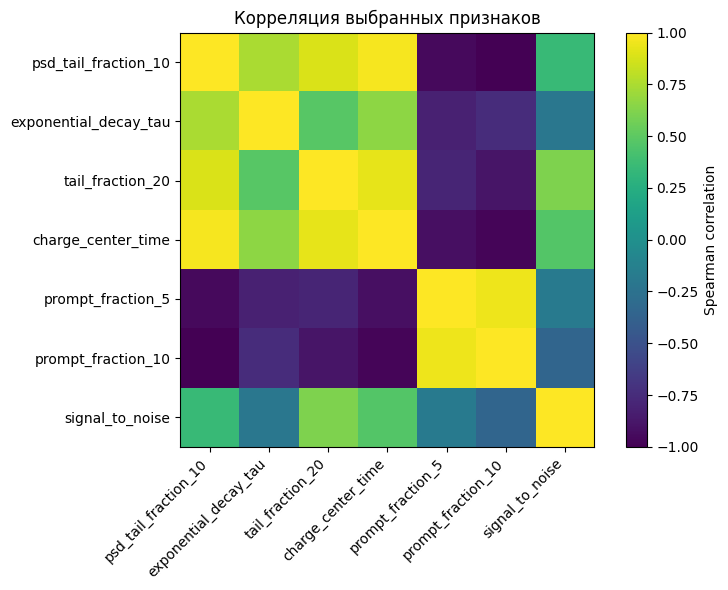

In [8]:
selected_feature_names = [
    "psd_tail_fraction_10",
    "exponential_decay_tau",
    "tail_fraction_20",
    "charge_center_time",
    "prompt_fraction_5",
    "prompt_fraction_10",
    "signal_to_noise",
]

selected_feature_table = signal_feature_table[selected_feature_names].copy()
feature_correlation_matrix = selected_feature_table.corr(method="spearman")

display(feature_correlation_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(feature_correlation_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(
    ticks=np.arange(len(selected_feature_names)),
    labels=selected_feature_names,
    rotation=45,
    ha="right",
)
plt.yticks(ticks=np.arange(len(selected_feature_names)), labels=selected_feature_names)
plt.title("Корреляция выбранных признаков")
plt.tight_layout()
plt.show()


Доля объяснённой дисперсии PCA:
[0.51642663 0.41907876]


,pca_loading_importance
signal_to_noise,1.341404
charge_center_time,0.620307
exponential_decay_tau,0.597318
prompt_fraction_5,0.578372
psd_tail_fraction_10,0.568091
prompt_fraction_10,0.568091
tail_fraction_20,0.459385


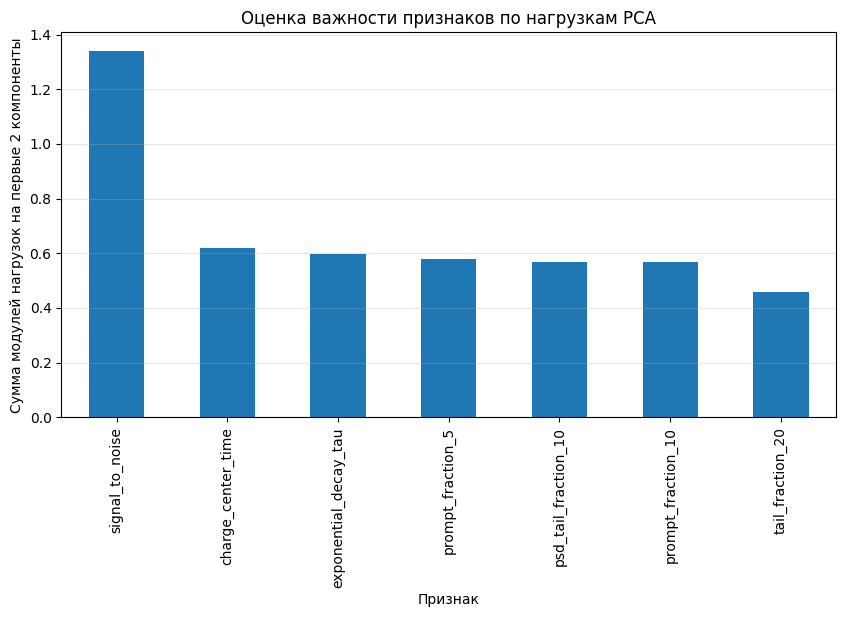

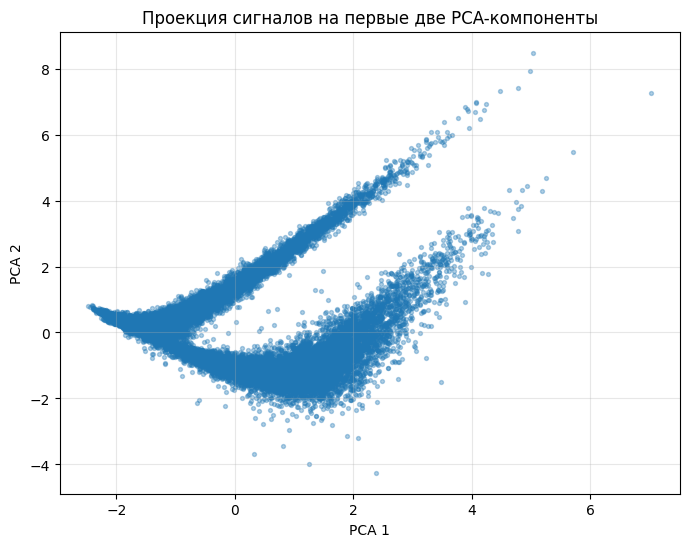

In [9]:
preprocessing_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

scaled_feature_matrix = preprocessing_pipeline.fit_transform(selected_feature_table)

pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
pca_projection = pca_model.fit_transform(scaled_feature_matrix)

pca_loading_importance = pd.Series(
    np.abs(pca_model.components_).sum(axis=0),
    index=selected_feature_names,
    name="pca_loading_importance",
).sort_values(ascending=False)

print("Доля объяснённой дисперсии PCA:")
print(pca_model.explained_variance_ratio_)

display(pca_loading_importance.to_frame())

plt.figure(figsize=(10, 5))
pca_loading_importance.plot(kind="bar")
plt.title("Оценка важности признаков по нагрузкам PCA")
plt.xlabel("Признак")
plt.ylabel("Сумма модулей нагрузок на первые 2 компоненты")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(pca_projection[:, 0], pca_projection[:, 1], s=8, alpha=0.35)
plt.title("Проекция сигналов на первые две PCA-компоненты")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.3)
plt.show()


### Вывод по признакам

Для финальной кластеризации используются признаки, связанные с PSD-разделением и формой хвоста импульса: psd_tail_fraction_10, exponential_decay_tau, tail_fraction_20, charge_center_time, prompt_fraction_5, prompt_fraction_10 и signal_to_noise.

Такой набор признаков имеет физический смысл: гамма-кванты и нейтроны могут иметь близкие амплитуды, но различаться по доле хвостовой части, времени затухания и временному центру сигнала. Анализ PCA и post-hoc важности показывает, что наибольший вклад в разделение дают signal_to_noise, charge_center_time, exponential_decay_tau и PSD-признаки. Масштабирование выполняется после отбора признаков, чтобы признаки с большими численными диапазонами не доминировали в расстояниях.


## 5. Сравнение моделей и подбор гиперпараметров

Сравниваются несколько подходов:

1. IsolationForest + KMeans — сначала отделяем аномальные сигналы, затем делим оставшиеся на два типа частиц;
2. KMeans на 3 кластера;
3. GaussianMixture на 3 компоненты;
4. BIRCH на 3 кластера.

Так как истинные метки неизвестны, качество сравнивается по внутренним метрикам кластеризации: silhouette_score, Calinski-Harabasz, Davies-Bouldin, а также по доле аномального кластера и интерпретируемости кластеров.


In [10]:
psd_values = signal_feature_table["psd_tail_fraction_10"].to_numpy()


def map_two_particle_labels(
    raw_particle_labels: np.ndarray,
    particle_psd_values: np.ndarray,
) -> np.ndarray:
    """Map two particle clusters to stable labels using mean PSD."""
    cluster_summary = (
        pd.DataFrame(
            {
                "raw_label": raw_particle_labels,
                "psd": particle_psd_values,
            }
        )
        .groupby("raw_label")
        .agg(mean_psd=("psd", "mean"))
    )

    high_psd_raw_label = cluster_summary["mean_psd"].idxmax()
    low_psd_raw_label = cluster_summary["mean_psd"].idxmin()

    mapped_labels = np.empty_like(raw_particle_labels, dtype=int)
    mapped_labels[raw_particle_labels == high_psd_raw_label] = HIGH_PSD_PARTICLE_CLUSTER
    mapped_labels[raw_particle_labels == low_psd_raw_label] = LOW_PSD_PARTICLE_CLUSTER
    return mapped_labels


def map_three_cluster_labels(
    raw_cluster_labels: np.ndarray,
    all_psd_values: np.ndarray,
) -> np.ndarray:
    """Map three unsupervised clusters to Kaggle labels 0, 1, 2."""
    cluster_summary = (
        pd.DataFrame(
            {
                "raw_label": raw_cluster_labels,
                "psd": all_psd_values,
            }
        )
        .groupby("raw_label")
        .agg(cluster_size=("psd", "size"), mean_psd=("psd", "mean"))
    )

    if len(cluster_summary) < 3:
        return np.full(len(raw_cluster_labels), ANOMALY_CLUSTER, dtype=int)

    anomaly_raw_label = cluster_summary["cluster_size"].idxmin()
    particle_raw_labels = [
        label for label in cluster_summary.index if label != anomaly_raw_label
    ]

    particle_summary = cluster_summary.loc[particle_raw_labels]
    high_psd_raw_label = particle_summary["mean_psd"].idxmax()
    low_psd_raw_label = particle_summary["mean_psd"].idxmin()

    mapped_labels = np.full(len(raw_cluster_labels), ANOMALY_CLUSTER, dtype=int)
    mapped_labels[raw_cluster_labels == high_psd_raw_label] = HIGH_PSD_PARTICLE_CLUSTER
    mapped_labels[raw_cluster_labels == low_psd_raw_label] = LOW_PSD_PARTICLE_CLUSTER
    mapped_labels[raw_cluster_labels == anomaly_raw_label] = ANOMALY_CLUSTER
    return mapped_labels


def evaluate_cluster_labels(
    scaled_features: np.ndarray,
    cluster_labels: np.ndarray,
    metric_indices: np.ndarray,
) -> dict[str, float]:
    """Calculate internal clustering metrics on a fixed sample."""
    sampled_features = scaled_features[metric_indices]
    sampled_labels = cluster_labels[metric_indices]
    unique_sampled_labels = np.unique(sampled_labels)

    result = {
        "silhouette_score": np.nan,
        "calinski_harabasz_score": np.nan,
        "davies_bouldin_score": np.nan,
        "anomaly_share": float(np.mean(cluster_labels == ANOMALY_CLUSTER)),
        "cluster_0_share": float(np.mean(cluster_labels == 0)),
        "cluster_1_share": float(np.mean(cluster_labels == 1)),
        "cluster_2_share": float(np.mean(cluster_labels == 2)),
    }

    if len(unique_sampled_labels) < 2 or len(unique_sampled_labels) >= len(sampled_labels):
        return result

    try:
        result["silhouette_score"] = float(
            silhouette_score(sampled_features, sampled_labels)
        )
    except Exception:
        pass

    try:
        result["calinski_harabasz_score"] = float(
            calinski_harabasz_score(sampled_features, sampled_labels)
        )
    except Exception:
        pass

    try:
        result["davies_bouldin_score"] = float(
            davies_bouldin_score(sampled_features, sampled_labels)
        )
    except Exception:
        pass

    return result


In [ ]:
metric_sample_size = min(3_000, len(scaled_feature_matrix))
metric_indices = random_generator.choice(
    np.arange(len(scaled_feature_matrix)),
    size=metric_sample_size,
    replace=False,
)

comparison_records: list[dict[str, object]] = []
candidate_label_sets: dict[str, np.ndarray] = {}


def register_candidate(
    candidate_id: str,
    model_name: str,
    parameters: dict[str, object],
    candidate_labels: np.ndarray,
) -> None:
    """Store labels and evaluation metrics for one candidate model."""
    candidate_label_sets[candidate_id] = candidate_labels.copy()
    metric_values = evaluate_cluster_labels(
        scaled_feature_matrix,
        candidate_labels,
        metric_indices,
    )
    comparison_records.append(
        {
            "candidate_id": candidate_id,
            "model_name": model_name,
            "parameters": parameters,
            **metric_values,
        }
    )


for contamination_fraction in [0.04, 0.06, 0.08]:
    for kmeans_n_init in [20, 50]:
        anomaly_detector = IsolationForest(
            contamination=contamination_fraction,
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        inlier_mask = anomaly_detector.fit_predict(scaled_feature_matrix[:, :4]) == 1

        if inlier_mask.sum() < 2:
            continue

        particle_clusterer = KMeans(
            n_clusters=2,
            n_init=kmeans_n_init,
            random_state=RANDOM_STATE,
        )
        raw_particle_labels = particle_clusterer.fit_predict(
            scaled_feature_matrix[inlier_mask]
        )

        candidate_labels = np.full(
            len(scaled_feature_matrix),
            ANOMALY_CLUSTER,
            dtype=int,
        )
        candidate_labels[inlier_mask] = map_two_particle_labels(
            raw_particle_labels,
            psd_values[inlier_mask],
        )

        register_candidate(
            candidate_id=(
                "isolation_forest_kmeans__"
                f"contamination_{contamination_fraction}__ninit_{kmeans_n_init}"
            ),
            model_name="IsolationForest+KMeans",
            parameters={
                "contamination": contamination_fraction,
                "kmeans_n_init": kmeans_n_init,
            },
            candidate_labels=candidate_labels,
        )


for kmeans_n_init in [20, 50, 100]:
    direct_kmeans_clusterer = KMeans(
        n_clusters=3,
        n_init=kmeans_n_init,
        random_state=RANDOM_STATE,
    )
    raw_cluster_labels = direct_kmeans_clusterer.fit_predict(scaled_feature_matrix)
    candidate_labels = map_three_cluster_labels(raw_cluster_labels, psd_values)

    register_candidate(
        candidate_id=f"kmeans_3__ninit_{kmeans_n_init}",
        model_name="KMeans-3",
        parameters={"n_init": kmeans_n_init},
        candidate_labels=candidate_labels,
    )


for covariance_type in ["full", "diag", "tied", "spherical"]:
    gaussian_mixture_clusterer = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        n_init=5,
        random_state=RANDOM_STATE,
    )
    raw_cluster_labels = gaussian_mixture_clusterer.fit_predict(scaled_feature_matrix)
    candidate_labels = map_three_cluster_labels(raw_cluster_labels, psd_values)

    register_candidate(
        candidate_id=f"gmm_3__covariance_{covariance_type}",
        model_name="GaussianMixture-3",
        parameters={"covariance_type": covariance_type},
        candidate_labels=candidate_labels,
    )


# 4. BIRCH на 3 кластера
for birch_threshold in [0.30, 0.50, 0.80]:
    birch_clusterer = Birch(
        n_clusters=3,
        threshold=birch_threshold,
    )
    raw_cluster_labels = birch_clusterer.fit_predict(scaled_feature_matrix)
    candidate_labels = map_three_cluster_labels(raw_cluster_labels, psd_values)

    register_candidate(
        candidate_id=f"birch_3__threshold_{birch_threshold}",
        model_name="BIRCH-3",
        parameters={"threshold": birch_threshold},
        candidate_labels=candidate_labels,
    )

comparison_table = pd.DataFrame(comparison_records)
comparison_table = comparison_table.sort_values(
    by=["silhouette_score", "davies_bouldin_score"],
    ascending=[False, True],
).reset_index(drop=True)

display(comparison_table)


,candidate_id,model_name,parameters,silhouette_score,calinski_harabasz_score,davies_bouldin_score,anomaly_share,cluster_0_share,cluster_1_share,cluster_2_share
0,kmeans_3__ninit_20,KMeans-3,{'n_init': 20},0.538461,3302.929680,0.684087,0.117083,0.403722,0.479194,0.117083
1,kmeans_3__ninit_50,KMeans-3,{'n_init': 50},0.538461,3302.929680,0.684087,0.117126,0.403850,0.479024,0.117126
2,kmeans_3__ninit_100,KMeans-3,{'n_init': 100},0.538461,3302.929680,0.684087,0.117126,0.403850,0.479024,0.117126
3,gmm_3__covariance_spherical,GaussianMixture-3,{'covariance_type': 'spherical'},0.494903,2681.001324,0.893692,0.204268,0.410026,0.385706,0.204268
4,gmm_3__covariance_tied,GaussianMixture-3,{'covariance_type': 'tied'},0.494063,2549.875786,0.697306,0.085779,0.349120,0.565101,0.085779
5,birch_3__threshold_0.5,BIRCH-3,{'threshold': 0.5},0.453136,528.313658,0.790087,0.002470,0.086120,0.911410,0.002470
6,birch_3__threshold_0.8,BIRCH-3,{'threshold': 0.8},0.437567,486.361829,0.783234,0.002683,0.071724,0.925593,0.002683
7,isolation_forest_kmeans__contamination_0.04__n...,IsolationForest+KMeans,"{'contamination': 0.04, 'kmeans_n_init': 20}",0.425183,1147.677688,3.631411,0.040036,0.406491,0.553473,0.040036
8,isolation_forest_kmeans__contamination_0.04__n...,IsolationForest+KMeans,"{'contamination': 0.04, 'kmeans_n_init': 50}",0.425183,1147.677688,3.631411,0.040036,0.406491,0.553473,0.040036
9,isolation_forest_kmeans__contamination_0.06__n...,IsolationForest+KMeans,"{'contamination': 0.06, 'kmeans_n_init': 20}",0.410819,1083.825331,4.352133,0.060011,0.392734,0.547255,0.060011


### Выбор финальной модели

По внутренним метрикам прямой KMeans на 3 кластера даёт самый высокий silhouette_score, однако такой подход не гарантирует, что третий кластер будет именно группой аномальных или неоднозначных сигналов.

Финальным вариантом оставлен подход IsolationForest + KMeans. Он лучше соответствует постановке задачи: два основных кластера соответствуют двум типам частиц, а третий класс формируется как отдельная группа аномалий. В текущем запуске выбран вариант с contamination = 0.04 и kmeans_n_init = 20.

Внутренние метрики полезны для сравнения моделей, но итоговое качество нужно дополнительно проверять на Kaggle. Если после отправки окажется, что кластеры 0 и 1 перепутаны, достаточно поменять значения HIGH_PSD_PARTICLE_CLUSTER и LOW_PSD_PARTICLE_CLUSTER в начале ноутбука и заново сформировать submission.csv.


In [12]:
isolation_forest_results = comparison_table[
    comparison_table["model_name"] == "IsolationForest+KMeans"
].copy()

if isolation_forest_results.empty:
    selected_model_row = comparison_table.iloc[0]
else:
    selected_model_row = isolation_forest_results.sort_values(
        by=["silhouette_score", "davies_bouldin_score"],
        ascending=[False, True],
    ).iloc[0]

selected_candidate_id = str(selected_model_row["candidate_id"])
final_labels_for_valid_signals = candidate_label_sets[selected_candidate_id]

valid_signal_indices = signal_feature_table["source_index"].astype(int).to_numpy()
final_cluster_labels = np.full(
    corrected_waveforms.shape[0],
    ANOMALY_CLUSTER,
    dtype=int,
)
final_cluster_labels[valid_signal_indices] = final_labels_for_valid_signals

signal_feature_table = signal_feature_table.copy()
signal_feature_table["cluster"] = final_labels_for_valid_signals

print("Выбранная модель:")
display(selected_model_row.to_frame().T)

print("Распределение финальных кластеров по всем сигналам:")
display(
    pd.Series(final_cluster_labels, name="cluster")
    .value_counts()
    .sort_index()
    .to_frame("signal_count")
)


Выбранная модель:


,candidate_id,model_name,parameters,silhouette_score,calinski_harabasz_score,davies_bouldin_score,anomaly_share,cluster_0_share,cluster_1_share,cluster_2_share
7,isolation_forest_kmeans__contamination_0.04__n...,IsolationForest+KMeans,"{'contamination': 0.04, 'kmeans_n_init': 20}",0.425183,1147.677688,3.631411,0.040036,0.406491,0.553473,0.040036


Распределение финальных кластеров по всем сигналам:


,signal_count
cluster,
0,9544
1,12995
2,940


## 6. Интерпретация кластеров

После получения меток важно проверить, что кластеры имеют физический смысл: основные классы должны отличаться по PSD-признакам, времени затухания и форме хвоста, а класс 2 должен содержать менее типичные или шумовые формы.


peak_amplitude                                   total_integral  \
                 count         mean  median          std          count   
cluster                                                                   
0                 9544  1557.842278  911.76  1699.143957           9544   
1                12995  2001.485939  723.20  2722.458652          12995   
2                  940  2333.579638  882.59  3068.862140            940   

                                             psd_tail_fraction_10            \
                 mean   median           std                count      mean   
cluster                                                                       
0        10490.843544  6758.19  10283.294533                 9544  0.229229   
1         9805.414015  3685.84  13022.068106                12995  0.077883   
2        14786.912830  6758.88  18033.332854                  940  0.233660   

         ... tail_fraction_20           charge_center_time            \
         ...           median       std              count      mean   
cluster  ...                                                           
0        ...         0.117742  0.047635               9544  7.649158   
1        ...         0.003206  0.018944              12995  3.501635   
2        ...         0.151753  0.071863                940  8.845210   

                            signal_to_noise                           \
           median       std           count         mean      median   
cluster                                                                
0        7.522393  2.017080            9544   841.149329  489.735777   
1        3.404727  0.770386           12995  1087.228104  386.078469   
2        9.765154  3.678060             940  1329.098550  483.721897   

                      
                 std  
cluster               
0         933.210257  
1        1514.360026  
2        1776.833576  

[3 rows x 28 columns]

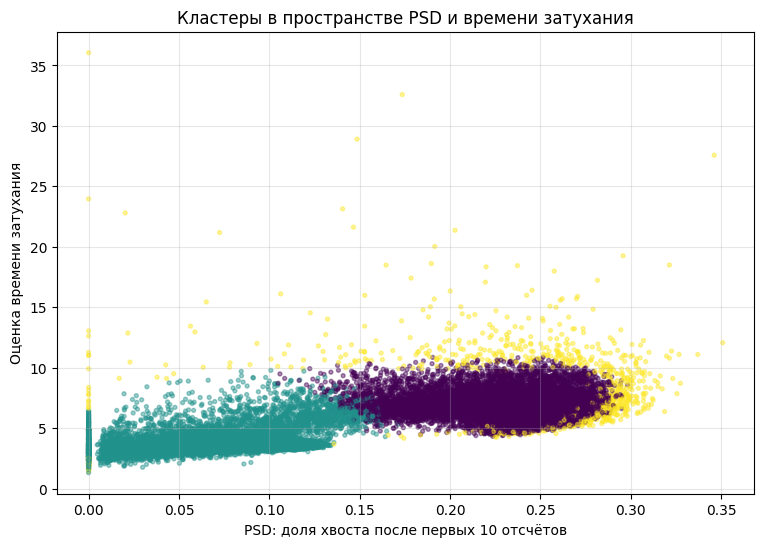

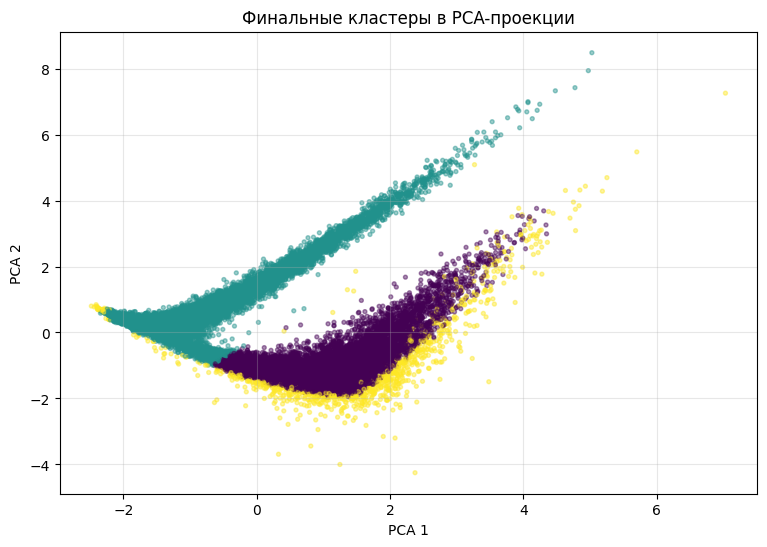

In [13]:
cluster_profile_table = signal_feature_table.groupby("cluster")[
    [
        "peak_amplitude",
        "total_integral",
        "psd_tail_fraction_10",
        "exponential_decay_tau",
        "tail_fraction_20",
        "charge_center_time",
        "signal_to_noise",
    ]
].agg(["count", "mean", "median", "std"])

display(cluster_profile_table)

plt.figure(figsize=(9, 6))
plt.scatter(
    signal_feature_table["psd_tail_fraction_10"],
    signal_feature_table["exponential_decay_tau"],
    c=signal_feature_table["cluster"],
    s=8,
    alpha=0.45,
)
plt.title("Кластеры в пространстве PSD и времени затухания")
plt.xlabel("PSD: доля хвоста после первых 10 отсчётов")
plt.ylabel("Оценка времени затухания")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 6))
plt.scatter(
    pca_projection[:, 0],
    pca_projection[:, 1],
    c=final_labels_for_valid_signals,
    s=8,
    alpha=0.45,
)
plt.title("Финальные кластеры в PCA-проекции")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.3)
plt.show()


,posthoc_feature_importance
exponential_decay_tau,0.239673
psd_tail_fraction_10,0.185479
prompt_fraction_10,0.183604
charge_center_time,0.137838
prompt_fraction_5,0.121200
tail_fraction_20,0.074239
signal_to_noise,0.057967


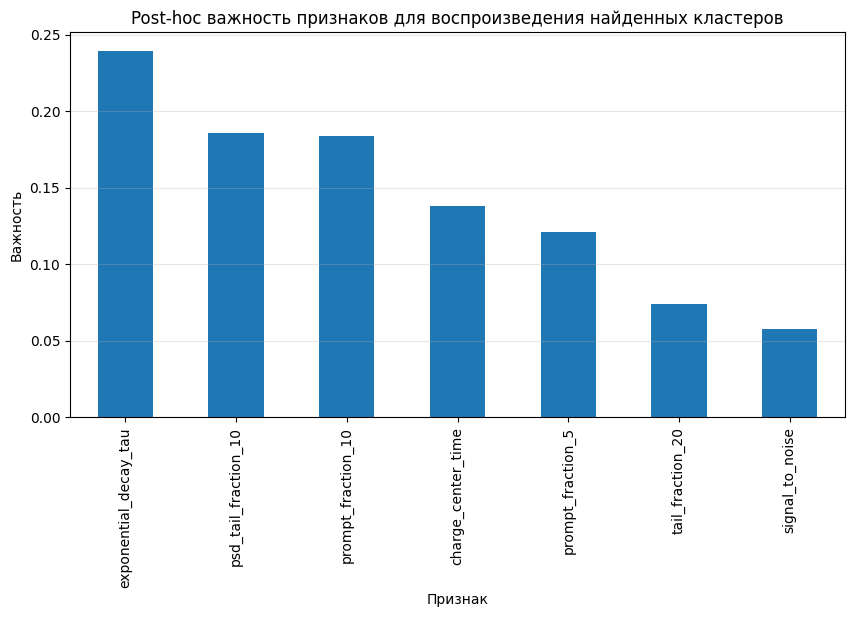

In [14]:
feature_interpretation_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
feature_interpretation_model.fit(selected_feature_table, final_labels_for_valid_signals)

posthoc_feature_importance = pd.Series(
    feature_interpretation_model.feature_importances_,
    index=selected_feature_names,
    name="posthoc_feature_importance",
).sort_values(ascending=False)

display(posthoc_feature_importance.to_frame())

plt.figure(figsize=(10, 5))
posthoc_feature_importance.plot(kind="bar")
plt.title("Post-hoc важность признаков для воспроизведения найденных кластеров")
plt.xlabel("Признак")
plt.ylabel("Важность")
plt.grid(axis="y", alpha=0.3)
plt.show()


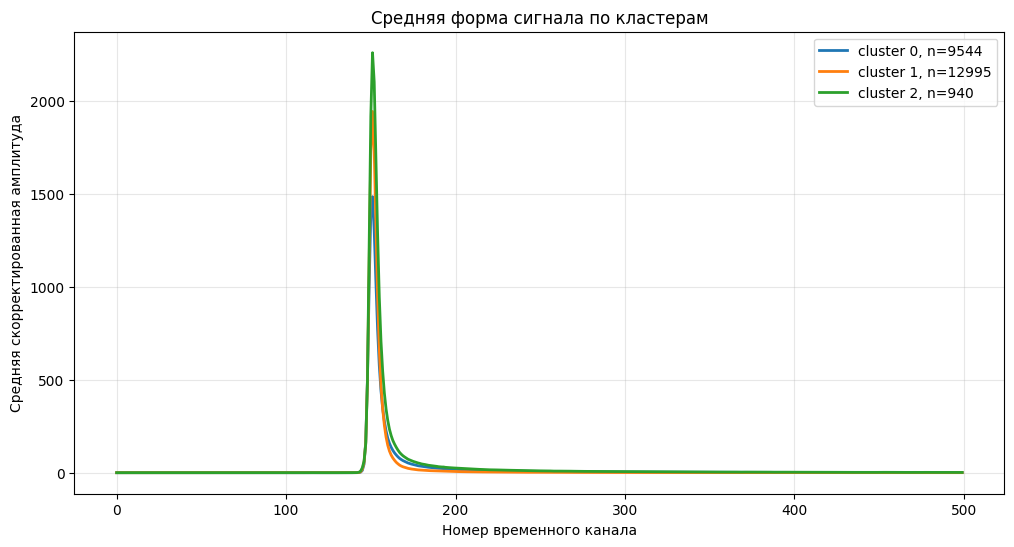

In [15]:
max_waveforms_for_cluster_mean = 3_000

plt.figure(figsize=(12, 6))
for cluster_id in [0, 1, 2]:
    cluster_signal_indices = np.flatnonzero(final_cluster_labels == cluster_id)

    if len(cluster_signal_indices) == 0:
        continue

    sampled_cluster_indices = cluster_signal_indices[:max_waveforms_for_cluster_mean]
    mean_cluster_waveform = corrected_waveforms.iloc[sampled_cluster_indices].mean(axis=0)

    plt.plot(
        mean_cluster_waveform.index,
        mean_cluster_waveform.values,
        label=f"cluster {cluster_id}, n={len(cluster_signal_indices)}",
        linewidth=2,
    )

plt.title("Средняя форма сигнала по кластерам")
plt.xlabel("Номер временного канала")
plt.ylabel("Средняя скорректированная амплитуда")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Вывод по интерпретации

- Кластеры 0 и 1 интерпретируются как два основных физических типа сигналов. Их ключевое отличие связано с PSD-признаками и параметрами хвоста импульса.  
- Кластер 2 формируется как группа аномальных или неоднозначных сигналов: слабые импульсы, выбросы, смешанные формы или сигналы с нестандартным хвостом.  
- В текущем запуске распределение получилось следующим: кластер 0 — 9544 сигнала, кластер 1 — 12995 сигналов, кластер 2 — 940 сигналов. Доля кластера 2 близка к выбранному уровню contamination = 0.04.  
- Post-hoc важность признаков помогает проверить, какие параметры сильнее всего влияют на разделение, но не является обучением по истинным меткам: это интерпретация уже найденных кластеров.


## 7. Формирование файла для Kaggle

Kaggle ожидает таблицу с двумя столбцами:

- index — номер сигнала;
- cluster — предсказанный кластер 0, 1 или 2.


In [ ]:
submission_table = pd.DataFrame(
    {
        "index": np.arange(len(final_cluster_labels)),
        "cluster": final_cluster_labels.astype(int),
    }
)

assert len(submission_table) == corrected_waveforms.shape[0]
assert submission_table["cluster"].isin([0, 1, 2]).all()
assert submission_table["index"].is_monotonic_increasing

submission_file_path = Path("submission.csv")

submission_table.to_csv(submission_file_path, index=False)


display(submission_table.head(10))
display(submission_table["cluster"].value_counts().sort_index().to_frame("signal_count"))


Файл сохранён: /Users/iakarpov/Desktop/iasitnikova/ml_s_5/submission.csv


,index,cluster
0,0,1
1,1,1
2,2,1
3,3,0
4,4,1
5,5,1
6,6,0
7,7,1
8,8,1
9,9,0


,signal_count
cluster,
0,9544
1,12995
2,940


## 8. Итоговые выводы

1. После предобработки исходный набор содержит 23 479 сигнала и 500 временных каналов. Пропусков в данных не обнаружено.  
2. EDA показал, что пики сигналов расположены в узкой области около 150-го канала, а распределения амплитуд и интегралов имеют длинные хвосты. Поэтому для дальнейшей работы использованы устойчивые признаки формы импульса и RobustScaler.  
3. На этапе Feature Engineering извлечены физически интерпретируемые признаки: амплитуда пика, интегралы, PSD-доли хвоста, время затухания, временной центр сигнала, ширина импульса и отношение сигнал/шум. Технически слабых или некорректных сигналов при выбранных порогах не выявлено.  
4. Сравнены несколько моделей и гиперпараметров: IsolationForest + KMeans, KMeans, GaussianMixture и BIRCH. По внутренней метрике silhouette_score лучший результат даёт KMeans на 3 кластера, но финально выбран IsolationForest + KMeans, потому что он явно выделяет третий класс как группу аномальных или неоднозначных сигналов.  
5. В финальном варианте использованы параметры contamination = 0.04 и kmeans_n_init = 20. Получено распределение кластеров: 0 — 9544 сигнала, 1 — 12995 сигналов, 2 — 940 сигналов.  
6. Кластеры 0 и 1 интерпретируются как два основных типа частиц, а кластер 2 — как аномальные, смешанные или плохо идентифицируемые сигналы.  
7. Сформирован воспроизводимый файл submission.csv для отправки на Kaggle.

Практическая рекомендация: после отправки на Kaggle стоит проверить, не перепутаны ли метки двух физических кластеров. Если score заметно ниже ожидаемого, поменяйте местами HIGH_PSD_PARTICLE_CLUSTER и LOW_PSD_PARTICLE_CLUSTER и повторно сохраните submission.
